In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
import os
from sklearn.cluster import KMeans
import calendar
from io import StringIO
import matplotlib.dates as mdates
from PIL import Image
import matplotlib.patches as patches
import random
from tqdm import tqdm
import shutil
from sklearn.cluster import DBSCAN
from PIL import Image, ImageDraw, ImageFont
import re

# Set visualization styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.5)
plt.rcParams['figure.figsize'] = (12, 8)

In [29]:
BASE_DIR = '../data/CameraTrapDataset-Processed/processed_data'
OUTPUT_DIR = '../data/CameraTrapDataset-Processed/plots'

In [30]:
with open(os.path.join(BASE_DIR   , 'animal_detections.json'), 'r') as f:
    detections = json.load(f)

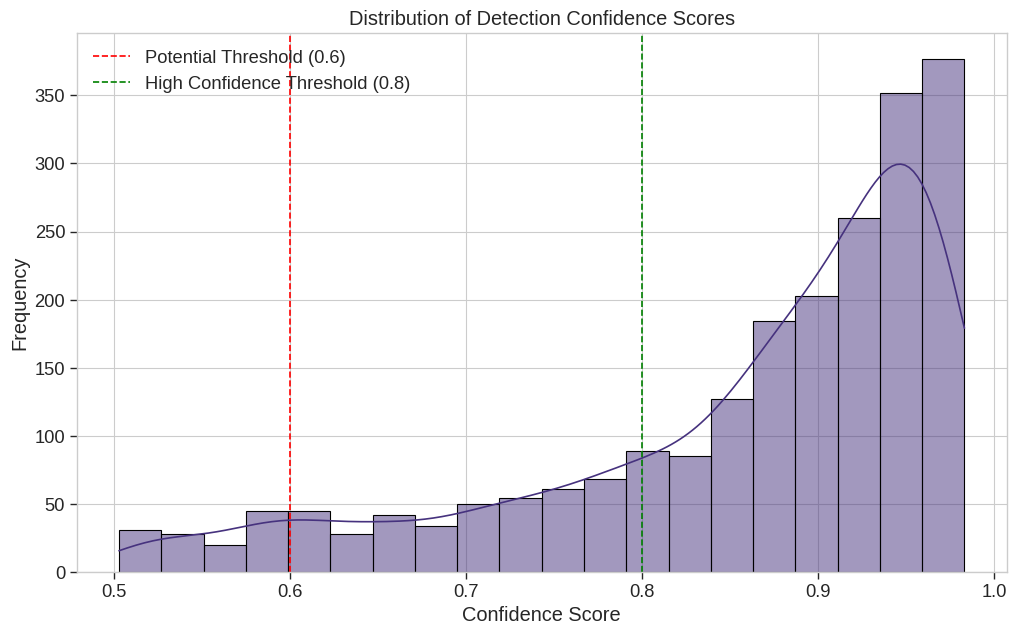

In [31]:
# Extract confidence scores
confidence_scores = []
for filename, detection_list in detections.items():
    for detection in detection_list:
        confidence_scores.append(detection['confidence'])

# Create histogram visualization
plt.figure(figsize=(12, 7))
sns.histplot(confidence_scores, bins=20, kde=True)
plt.axvline(x=0.6, color='red', linestyle='--', label='Potential Threshold (0.6)')
plt.axvline(x=0.8, color='green', linestyle='--', label='High Confidence Threshold (0.8)')
plt.title('Distribution of Detection Confidence Scores')
plt.xlabel('Confidence Score')
plt.ylabel('Frequency')
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, 'confidence_distribution.png'), dpi=300)
plt.show()

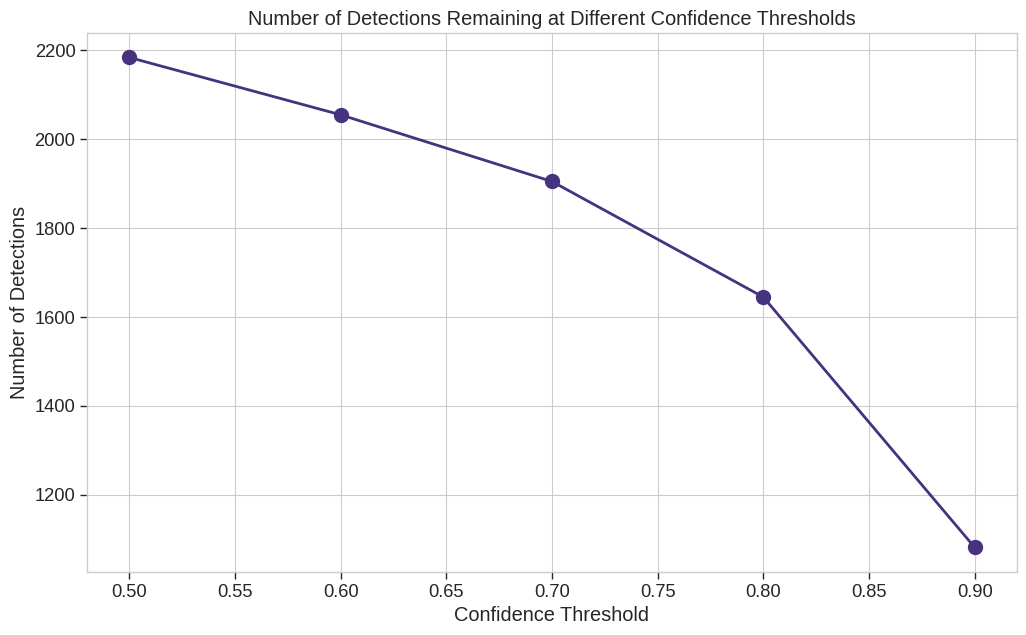

In [32]:
# Calculate cumulative detections at different thresholds
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]
detections_count = []

for threshold in thresholds:
    count = sum(1 for score in confidence_scores if score >= threshold)
    detections_count.append(count)

# Create line plot
plt.figure(figsize=(12, 7))
plt.plot(thresholds, detections_count, 'o-', linewidth=2, markersize=10)
plt.title('Number of Detections Remaining at Different Confidence Thresholds')
plt.xlabel('Confidence Threshold')
plt.ylabel('Number of Detections')
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, 'threshold_impact.png'), dpi=300)
plt.show()


In [42]:
data = pd.read_csv(os.path.join(BASE_DIR, 'trail_cam_data.csv'))

Number of April detections: 429
Identified 67 distinct animal encounter events
Average event duration: 0.26 minutes
Average images per event: 6.40


Events processing complete!


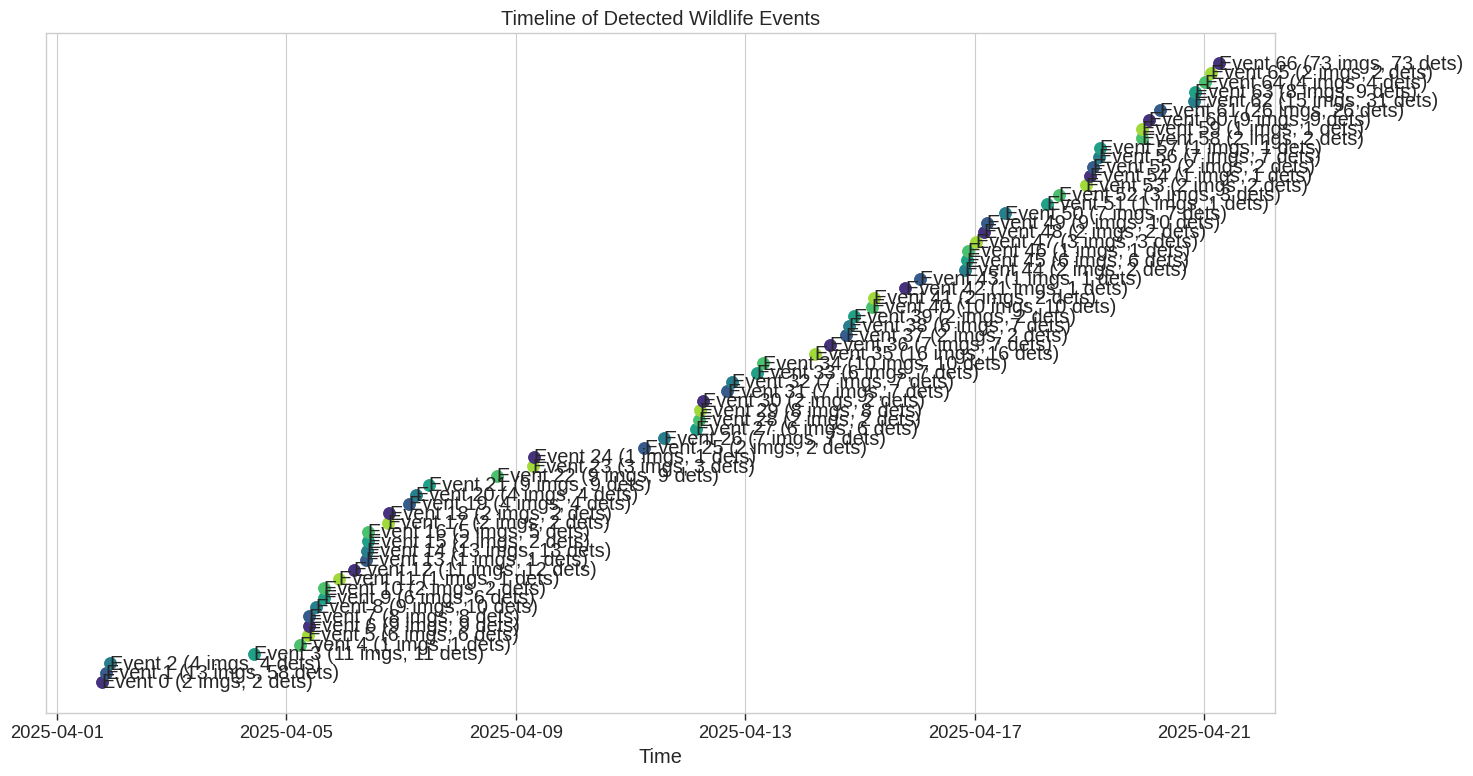

In [48]:
# Load your camera trap data
#data = pd.read_csv('processed_data/trail_cam_data.csv')
data['datetime'] = pd.to_datetime(data['datetime'])

# Filter data for April
data = data[data['datetime'].dt.month == 4]
print(f"Number of April detections: {len(april_data)}")

# Extract date and time features for April data
#data['date'] = data['datetime'].dt.date
#data['day'] = data['datetime'].dt.day
#data['day_of_week'] = data['datetime'].dt.day_name()
#data['hour'] = data['datetime'].dt.hour

# Define time of day categories
#data['time_of_day'] = pd.cut(data['hour'],
#                                  bins=[0, 6, 12, 18, 24],
#                                  labels=['Night', 'Morning', 'Afternoon', 'Evening'],
#                                  right=False)

# Convert timestamps to numerical format (seconds since epoch)
timestamps = data['datetime'].map(datetime.timestamp).values.reshape(-1, 1)

# Apply DBSCAN clustering on timestamps
# eps = 300 means events within 5 minutes (300 seconds) are clustered together
# min_samples = 1 means even a single image can form a cluster
dbscan = DBSCAN(eps=300, min_samples=1, metric='euclidean').fit(timestamps)

# Add cluster labels to the dataframe
data['event_id'] = dbscan.labels_

# Get event summary statistics
event_summary = data.groupby('event_id').agg(
    start_time=('datetime', 'min'),
    end_time=('datetime', 'max'),
    num_images=('filepath', 'count'),
    total_detections=('num_detections', 'sum')
).reset_index()

# Calculate event duration in minutes
event_summary['duration_minutes'] = (event_summary['end_time'] - 
                                   event_summary['start_time']).dt.total_seconds() / 60

# Print summary
print(f"Identified {len(event_summary)} distinct animal encounter events")
print(f"Average event duration: {event_summary['duration_minutes'].mean():.2f} minutes")
print(f"Average images per event: {event_summary['num_images'].mean():.2f}")

# Save the event summary to CSV
event_summary.to_csv(os.path.join(BASE_DIR, 'event_summary.csv'), index=False)

# Create folders for each event and save annotated images
#base_dir = 'processed_data/events'
#os.makedirs(base_dir, exist_ok=True)

# Load detection bounding boxes for annotation
with open(os.path.join(BASE_DIR, 'animal_detections.json'), 'r') as f:
    detections = json.load(f)

# Process each event
for event_id in event_summary['event_id'].unique():
    # Create event folder
    os.makedirs(os.path.join(OUTPUT_DIR, 'events'), exist_ok=True)
    events_parent_dir = os.path.join(OUTPUT_DIR, 'events')
    event_dir = os.path.join(events_parent_dir, f'event_{event_id}')
    os.makedirs(event_dir, exist_ok=True)
    
    
    # Get images for this event
    event_images = data[data['event_id'] == event_id]
    
    # Create a summary text file for this event
    with open(os.path.join(event_dir, 'summary.txt'), 'w') as f:
        event_data = event_summary[event_summary['event_id'] == event_id].iloc[0]
        f.write(f"Event ID: {event_id}\n")
        f.write(f"Start time: {event_data['start_time']}\n")
        f.write(f"End time: {event_data['end_time']}\n")
        f.write(f"Duration: {event_data['duration_minutes']:.2f} minutes\n")
        f.write(f"Number of images: {event_data['num_images']}\n")
        f.write(f"Total detections: {event_data['total_detections']}\n")
    
    # Process each image in the event
    for _, row in event_images.iterrows():
        # Get image filename
        filename = os.path.basename(row['filepath'])
        file_path = os.path.join('../data/CameraTrapDataset-Processed/processed_data/animal_images', os.path.basename(row['filepath']))
        
        # Load and annotate the image
        try:
            img = Image.open(file_path)
            draw = ImageDraw.Draw(img)
            
            # Add detections if available
            if filename in detections:
                for det in detections[filename]:
                    bbox = det['bbox']
                    conf = det['confidence']
                    
                    # Convert normalized coordinates to pixels
                    width, height = img.size
                    x, y, w, h = bbox
                    x1 = int(x * width)
                    y1 = int(y * height)
                    x2 = int((x + w) * width)
                    y2 = int((y + h) * height)
                    
                    # Draw bounding box
                    draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
                    draw.text((x1, y1), f"Conf: {conf:.2f}", fill="red")
            
            # Save annotated image
            img.save(os.path.join(event_dir, filename))
            
        except Exception as e:
            print(f"Error processing {filename}: {e}")

print("Events processing complete!")

# Create event timeline visualization
plt.figure(figsize=(15, 8))
for i, event in event_summary.iterrows():
    plt.plot([event['start_time'], event['end_time']], [i, i], 'o-', linewidth=2, 
             markersize=8, label=f"Event {event['event_id']}" if i == 0 else "")
    plt.text(event['end_time'] + pd.Timedelta(minutes=1), i, 
             f"Event {event['event_id']} ({event['num_images']} imgs, {event['total_detections']} dets)",
             verticalalignment='center')

plt.yticks([])
plt.xlabel('Time')
plt.title('Timeline of Detected Wildlife Events')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'event_timeline.png'), dpi=300)
plt.show()

/tmp/ipykernel_1583349/803627456.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([d.strftime('%b %d') for d in events_per_day['date']], rotation=45)


<Figure size 1600x1000 with 0 Axes>

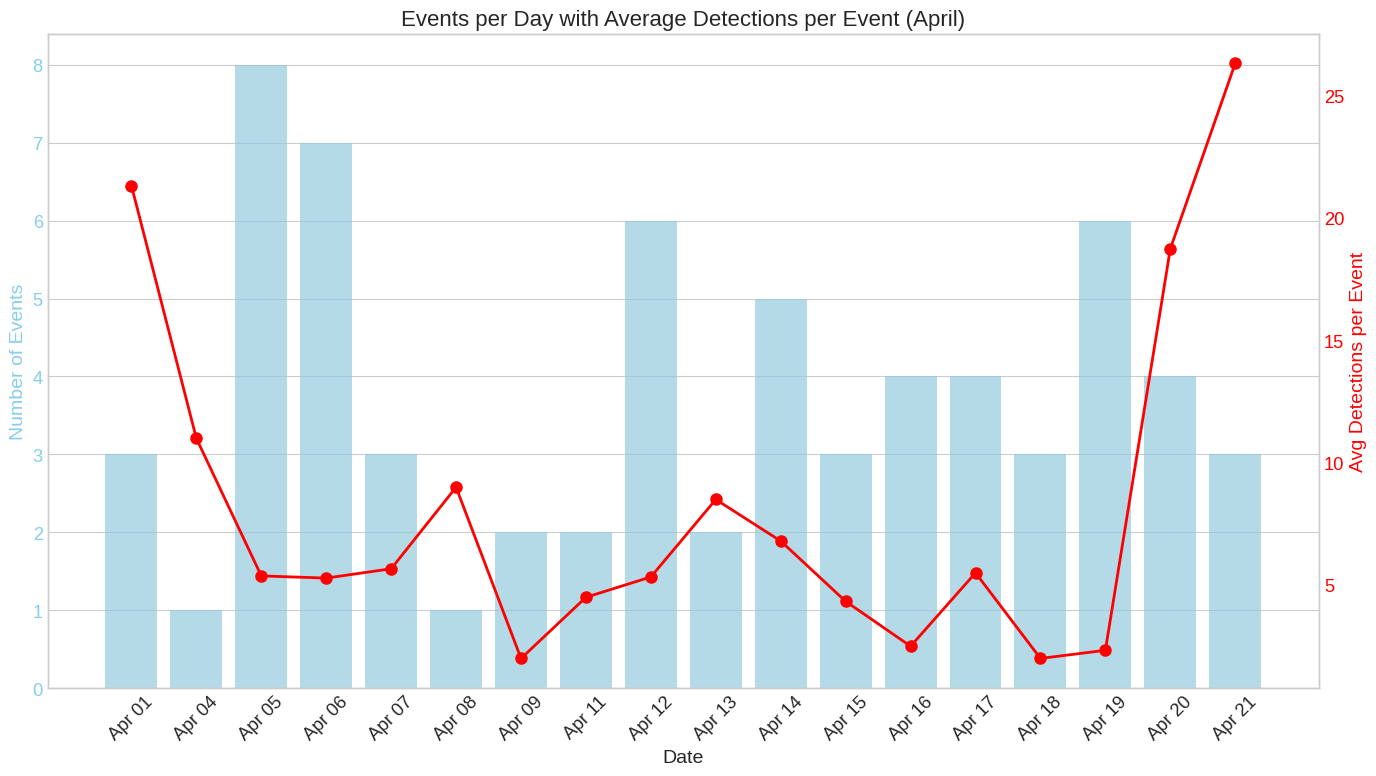

<Figure size 1400x800 with 0 Axes>

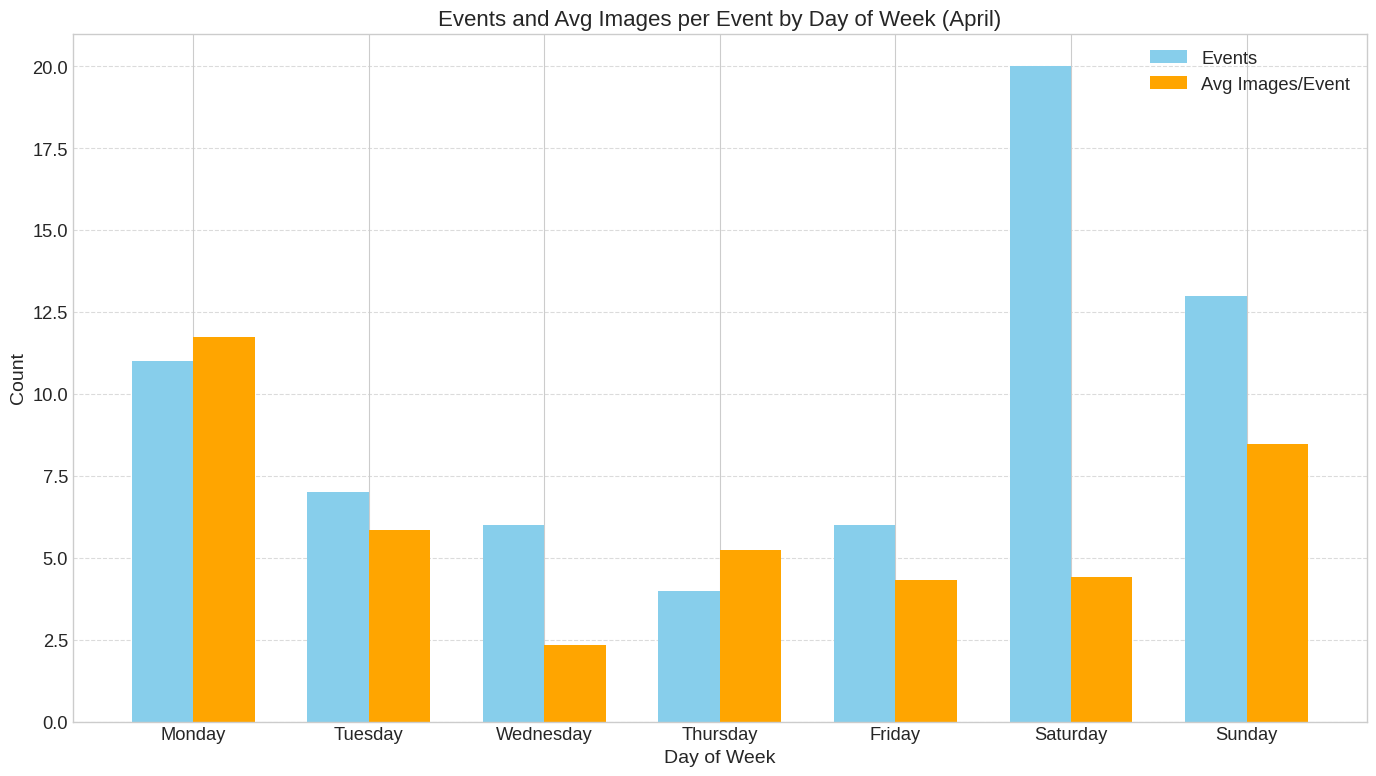

/tmp/ipykernel_1583349/803627456.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  events_per_tod = april_events.groupby('time_of_day').agg(


<Figure size 1400x800 with 0 Axes>

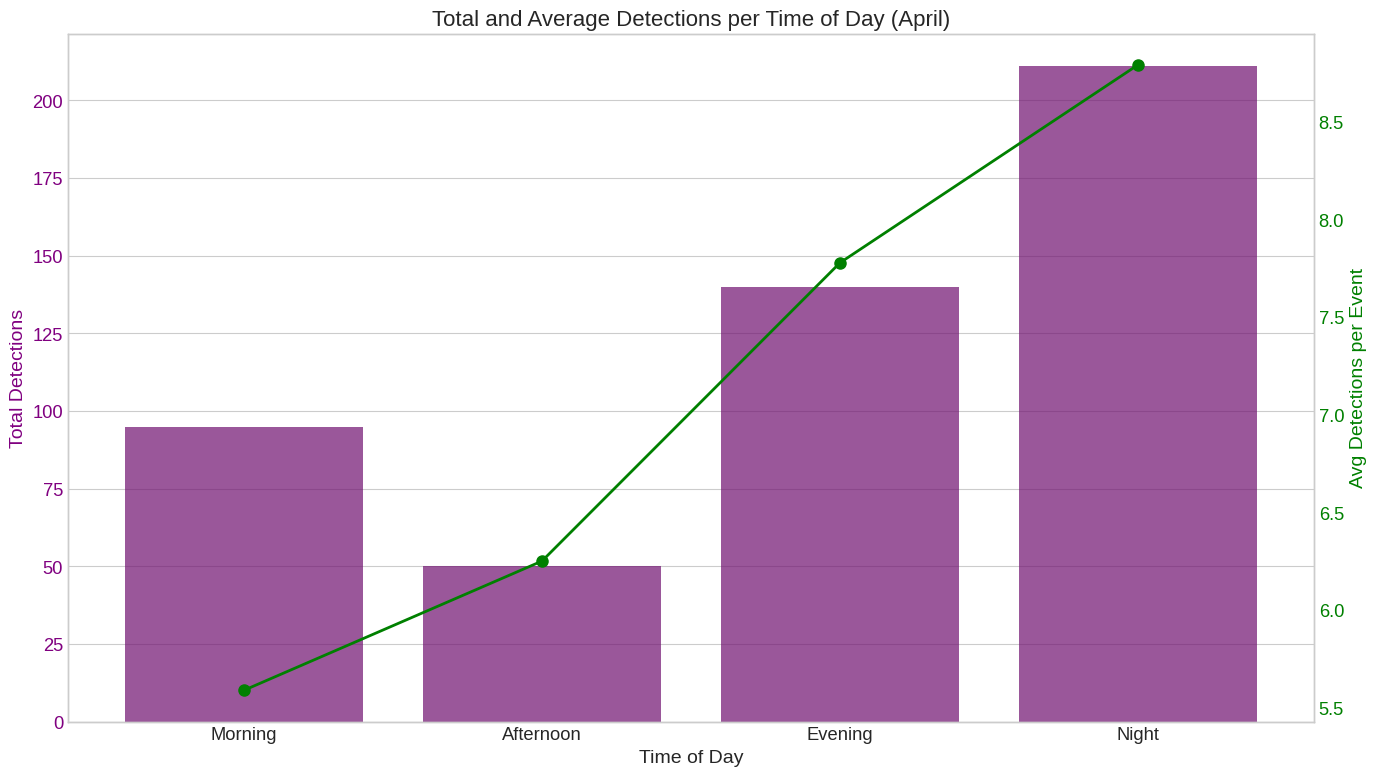

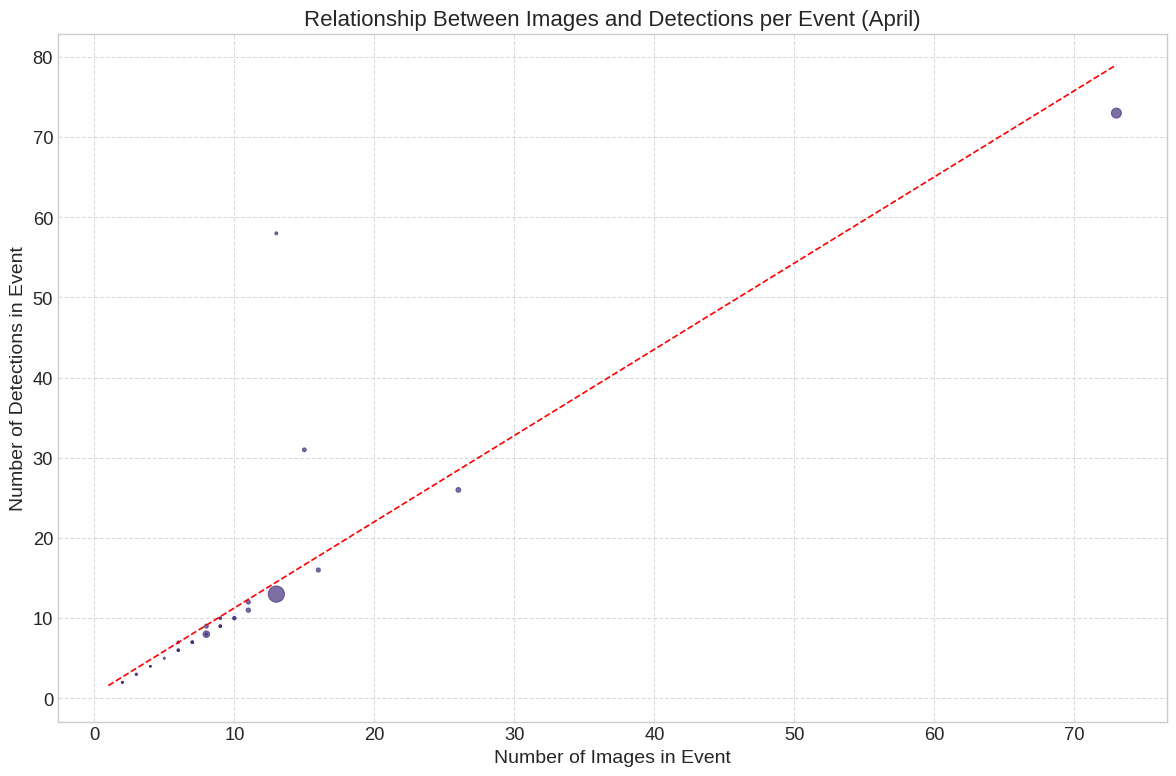

Total events: 67
Total detections: 496
Total images: 429
Avg detections per event: 7.402985074626866
Avg images per event: 6.402985074626866
Most active day: 2025-04-05
Most active day of week: Saturday
Most active time of day: Night
Day with most detections: 2025-04-21
Time of day with most detections: Night


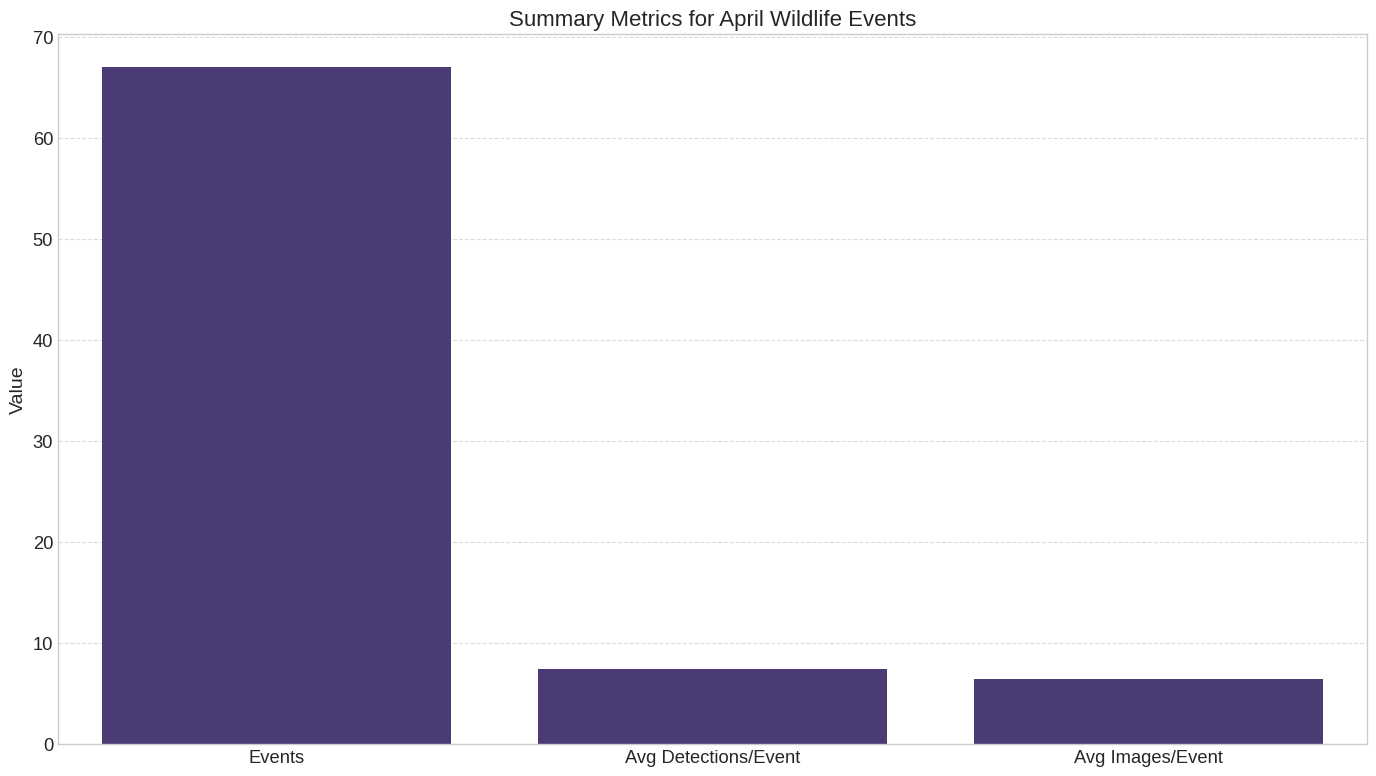

In [49]:
event_data = pd.read_csv('../data/CameraTrapDataset-Processed/processed_data/event_summary.csv')

# Convert start_time and end_time to datetime
event_data['start_time'] = pd.to_datetime(event_data['start_time'])
event_data['end_time'] = pd.to_datetime(event_data['end_time'])

# Filter for April data
april_events = event_data[event_data['start_time'].dt.month == 4]

# Extract date and time features
april_events['date'] = april_events['start_time'].dt.date
april_events['day_of_week'] = april_events['start_time'].dt.day_name()
april_events['hour'] = april_events['start_time'].dt.hour

# Define time of day categories
april_events['time_of_day'] = pd.cut(april_events['hour'],
                                    bins=[0, 6, 12, 18, 24],
                                    labels=['Night', 'Morning', 'Afternoon', 'Evening'],
                                    right=False)

# Create output directory for visualizations
output_dir = 'processed_data/visualizations/event_analysis'
os.makedirs(output_dir, exist_ok=True)

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

# 1. Events per day with detections and images
plt.figure(figsize=(16, 10))
events_per_day = april_events.groupby('date').agg(
    total_events=('event_id', 'count'),
    total_detections=('total_detections', 'sum'),
    total_images=('num_images', 'sum'),
    avg_detections_per_event=('total_detections', 'mean'),
    avg_images_per_event=('num_images', 'mean')
).reset_index()

# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()

# Plot events count bars
sns.barplot(x='date', y='total_events', data=events_per_day, color='skyblue', ax=ax1, alpha=0.7)
ax1.set_xlabel('Date', fontsize=14)
ax1.set_ylabel('Number of Events', fontsize=14, color='skyblue')
ax1.tick_params(axis='y', colors='skyblue')
ax1.set_xticklabels([d.strftime('%b %d') for d in events_per_day['date']], rotation=45)

# Plot average detections line
ax2.plot(range(len(events_per_day)), events_per_day['avg_detections_per_event'], 
         'o-', color='red', linewidth=2, markersize=8)
ax2.set_ylabel('Avg Detections per Event', fontsize=14, color='red')
ax2.tick_params(axis='y', colors='red')

plt.title('Events per Day with Average Detections per Event (April)', fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'events_and_detections_per_day.png'), dpi=300)
plt.show()

# 2. Events per day of week with total detections
plt.figure(figsize=(14, 8))
events_per_dow = april_events.groupby('day_of_week').agg(
    total_events=('event_id', 'count'),
    total_detections=('total_detections', 'sum'),
    total_images=('num_images', 'sum'),
    avg_detections_per_event=('total_detections', 'mean'),
    avg_images_per_event=('num_images', 'mean')
).reset_index()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
events_per_dow = events_per_dow.set_index('day_of_week').loc[days_order].reset_index()

# Create stacked bar chart
plt.figure(figsize=(14, 8))
width = 0.35
x = np.arange(len(days_order))

plt.bar(x, events_per_dow['total_events'], width, label='Events', color='skyblue')
plt.bar(x + width, events_per_dow['avg_images_per_event'], width, label='Avg Images/Event', color='orange')

plt.xlabel('Day of Week', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Events and Avg Images per Event by Day of Week (April)', fontsize=16)
plt.xticks(x + width/2, days_order)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'events_and_images_per_dow.png'), dpi=300)
plt.show()

# 3. Detections by time of day
plt.figure(figsize=(14, 8))
events_per_tod = april_events.groupby('time_of_day').agg(
    total_events=('event_id', 'count'),
    total_detections=('total_detections', 'sum'),
    avg_detections_per_event=('total_detections', 'mean')
).reset_index()

tod_order = ['Morning', 'Afternoon', 'Evening', 'Night']
events_per_tod = events_per_tod.set_index('time_of_day').loc[tod_order].reset_index()

fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()

# Plot total detections bars
sns.barplot(x='time_of_day', y='total_detections', data=events_per_tod, 
           color='purple', ax=ax1, alpha=0.7, order=tod_order)
ax1.set_xlabel('Time of Day', fontsize=14)
ax1.set_ylabel('Total Detections', fontsize=14, color='purple')
ax1.tick_params(axis='y', colors='purple')

# Plot average detections per event line
ax2.plot(range(len(tod_order)), events_per_tod['avg_detections_per_event'], 
         'o-', color='green', linewidth=2, markersize=8)
ax2.set_ylabel('Avg Detections per Event', fontsize=14, color='green')
ax2.tick_params(axis='y', colors='green')

plt.title('Total and Average Detections per Time of Day (April)', fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'detections_by_time_of_day.png'), dpi=300)
plt.show()

# 4. Scatter plot of images vs. detections per event
plt.figure(figsize=(12, 8))
plt.scatter(april_events['num_images'], april_events['total_detections'], 
           s=april_events['duration_minutes']*20, alpha=0.7)
plt.plot(np.unique(april_events['num_images']), 
         np.poly1d(np.polyfit(april_events['num_images'], april_events['total_detections'], 1))(np.unique(april_events['num_images'])), 
         color='red', linestyle='--')
plt.xlabel('Number of Images in Event', fontsize=14)
plt.ylabel('Number of Detections in Event', fontsize=14)
plt.title('Relationship Between Images and Detections per Event (April)', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'images_vs_detections.png'), dpi=300)
plt.show()

# 5. Comprehensive summary table
summary_stats = {
    'Total events': len(april_events),
    'Total detections': april_events['total_detections'].sum(),
    'Total images': april_events['num_images'].sum(),
    'Avg detections per event': april_events['total_detections'].mean(),
    'Avg images per event': april_events['num_images'].mean(),
    'Most active day': events_per_day.loc[events_per_day['total_events'].idxmax(), 'date'],
    'Most active day of week': events_per_dow.loc[events_per_dow['total_events'].idxmax(), 'day_of_week'],
    'Most active time of day': events_per_tod.loc[events_per_tod['total_events'].idxmax(), 'time_of_day'],
    'Day with most detections': events_per_day.loc[events_per_day['total_detections'].idxmax(), 'date'],
    'Time of day with most detections': events_per_tod.loc[events_per_tod['total_detections'].idxmax(), 'time_of_day']
}

# Display summary statistics
for key, value in summary_stats.items():
    print(f"{key}: {value}")

# Plot summary bar chart
plt.figure(figsize=(14, 8))
summary_df = pd.DataFrame({
    'Metric': ['Events', 'Avg Detections/Event', 'Avg Images/Event'],
    'Value': [len(april_events), april_events['total_detections'].mean(), april_events['num_images'].mean()]
})
sns.barplot(x='Metric', y='Value', data=summary_df)
plt.title('Summary Metrics for April Wildlife Events', fontsize=16)
plt.xlabel('')
plt.ylabel('Value', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'event_summary_metrics.png'), dpi=300)
plt.show()

In [ ]:
import subprocess


# Create directories for output
os.makedirs('..data/CameraTrapDataset-Processed/processed_data/species_classifications', exist_ok=True)
os.makedirs('..data/CameraTrapDataset-Processed/processed_data/visualizations/species_analysis', exist_ok=True)

# Step 1: Run SpeciesNet classification on your event folders
def classify_events_with_speciesnet(crops_dir, output_json):
    """
    Run SpeciesNet classification on event-grouped images
    """
    command = [
    "python", "-m", "speciesnet.scripts.run_model",
    "--folders", crops_dir,
    "--predictions_json", output_json,
    "--country", "HRV"
]
    
    print(f"Running SpeciesNet with command: {command}")
    subprocess.run(command)
    
    return output_json

In [ ]:
crops_dir = '..data/CameraTrapDataset-Processed/processed_data/animal_crops'
output_json = '..data/CameraTrapDataset-Processed/processed_data/species_classifications/speciesnet_results.json'

In [53]:
# Step 1: Load and filter trail_cam_data.csv to April only
def load_april_data(csv_path):
    # Load the trail cam data
    trail_data = pd.read_csv(csv_path)
    
    # Convert datetime column to datetime type
    trail_data['datetime'] = pd.to_datetime(trail_data['datetime'])
    
    # Filter for April 2025
    april_data = trail_data[trail_data['datetime'].dt.month == 4]
    
    # Extract base image ID from filepath (without extension)
    april_data['image_id'] = april_data['filepath'].apply(
        lambda x: os.path.splitext(os.path.basename(x))[0]
    )
    
    print(f"Found {len(april_data)} camera trap images from April 2025")
    return april_data

In [63]:
from speciesnet import SpeciesNetClassifier
from speciesnet import DEFAULT_MODEL
from tqdm import tqdm
import torch
SAVE_DIR = '../data/CameraTrapDataset-Processed/'

# Step 2: Find corresponding crops for each April image
def find_matching_crops(april_data, crops_dir):
    all_crops = []
    
    # Get list of all crop files
    crop_files = os.listdir(crops_dir) if os.path.exists(crops_dir) else []
    
    # For each April image, find its crops
    for _, row in april_data.iterrows():
        image_id = row['image_id']
        
        # Find crops that start with this image_id
        matching_crops = [f for f in crop_files if f.startswith(f"{image_id}_crop")]
        
        # Add each crop with its parent image metadata
        for crop_file in matching_crops:
            all_crops.append({
                'crop_filename': crop_file,
                'crop_path': os.path.join(crops_dir, crop_file),
                'parent_image_id': image_id,
                'parent_datetime': row['datetime'],
                'parent_filepath': row['filepath'],
                'num_detections': row['num_detections']
            })
    
    crops_df = pd.DataFrame(all_crops)
    print(f"Found {len(crops_df)} crop images from April 2025 camera trap images")
    return crops_df

# Step 3: Run SpeciesNet classification on the crop images
def classify_crops(crops_df):
    """
    Run SpeciesNet classification on the crop images
    """
    
    print("Running SpeciesNet classification on crop images...")
    
    # Set device (use GPU if available)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Initialize SpeciesNet model
    model = SpeciesNetClassifier(DEFAULT_MODEL)
    
    # Process images in batches to improve efficiency
    results = []
    
    # Process each crop with tqdm progress bar
    for _, row in tqdm(crops_df.iterrows(), total=len(crops_df), desc="Classifying crops"):

        # Load and preprocess image
        image = Image.open(row['crop_path'])
        
        # Run classification
        prediction = model.predict(filepath=row['crop_path'], img = None)
        print(prediction)
        
        # Extract top prediction
        top_pred = prediction.top_prediction
        
        results.append({
            'crop_filename': row['crop_filename'],
            'crop_path': row['crop_path'],
            'species': top_pred.scientific_name,
            'common_name': top_pred.common_name,
            'confidence': top_pred.confidence,
            'parent_image_id': row['parent_image_id'],
            'parent_datetime': row['parent_datetime']
        })

    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Save raw classification results to CSV
    output_path = SAVE_DIR + 'processed_data/species_classifications/speciesnet_results.csv'
    results_df.to_csv(output_path, index=False)
    print(f"Saved classification results to {output_path}")
    
    return results_df

# Step 4: Link classifications to events and analyze
def analyze_april_species(classification_results, event_data_path):
    """
    Link classifications to events and analyze species patterns
    """
    # Load event data
    event_data = pd.read_csv(event_data_path)
    event_data['start_time'] = pd.to_datetime(event_data['start_time'])
    event_data['end_time'] = pd.to_datetime(event_data['end_time'])
    
    # Link each classification to an event based on datetime
    classification_results['event_id'] = None
    
    for _, event in event_data.iterrows():
        mask = ((classification_results['parent_datetime'] >= event['start_time']) & 
                (classification_results['parent_datetime'] <= event['end_time']))
        classification_results.loc[mask, 'event_id'] = event['event_id']
    
    # Filter to linked classifications only
    linked_results = classification_results.dropna(subset=['event_id'])
    
    print(f"Linked {len(linked_results)} out of {len(classification_results)} classifications to events")
    
    # The rest of your analysis code would go here, similar to what we had before
    return linked_results

# Main workflow
def main():
    # Paths
    trail_cam_path = SAVE_DIR + 'processed_data/trail_cam_data.csv'
    crops_dir = SAVE_DIR + 'processed_data/animal_crops'
    event_data_path = SAVE_DIR + 'processed_data/event_summary.csv'
    output_dir = SAVE_DIR + 'processed_data/visualizations/species_analysis'
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. Load April data
    april_data = load_april_data(trail_cam_path)
    
    # 2. Find matching crop images
    crops_df = find_matching_crops(april_data, crops_dir)
    
    # 3. Run classification
    classification_results = classify_crops(crops_df)
    
    # 4. Link to events and analyze
    linked_results = analyze_april_species(classification_results, event_data_path)
    
    print("April species classification workflow complete!")

# Run the workflow
if __name__ == "__main__":
    main()

/tmp/ipykernel_1583349/674244545.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  april_data['image_id'] = april_data['filepath'].apply(


Found 429 camera trap images from April 2025
Found 496 crop images from April 2025 camera trap images
Running SpeciesNet classification on crop images...
Using device: cuda


Classifying crops:   0%|          | 0/496 [00:00<?, ?it/s]

{'filepath': '../data/CameraTrapDataset-Processed/processed_data/animal_crops/04010614_crop1_conf89.jpg', 'failures': ['CLASSIFIER']}


AttributeError: 'dict' object has no attribute 'top_prediction'